In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
# read data
df = pd.read_csv("../data/student_performance.csv")

# show data
print(df)

     Student_ID  Age  Gender  Study_Hours  Attendance(%)  Test_Score Grade
0         S0524   21  Female          2.7           74.0          37     F
1         S0603   19    Male          1.5           93.1          26     F
2         S0527   20  Female          6.8           97.2          88     A
3         S0032   18  Female          6.2           93.5          55     C
4         S0617   21    Male          7.4           99.2          77     B
...         ...  ...     ...          ...            ...         ...   ...
1015      S0107   22  Female          6.3           84.7          72     B
1016      S0271   22    Male          5.3          100.5          45     F
1017      S0861   21  Female          4.0          102.7          30     F
1018      S0436   18  Female          6.3           92.4          55     C
1019      S0103   21  Female          1.6          104.6          37     F

[1020 rows x 7 columns]


In [4]:
# first 5 rows
print("First 5 rows:")
print(df.head())
print("\n")

# shape of data
print("Shape of data:")
print(df.shape)
print("\n")

# name of columns
print("Name of columns:")
print(df.columns)
print("\n")

# information of data
print("Information of data:")
df.info()
print("\n")

# statistical description
print("Data describe:")
print(df.describe())
print("\n")

First 5 rows:
  Student_ID  Age  Gender  Study_Hours  Attendance(%)  Test_Score Grade
0      S0524   21  Female          2.7           74.0          37     F
1      S0603   19    Male          1.5           93.1          26     F
2      S0527   20  Female          6.8           97.2          88     A
3      S0032   18  Female          6.2           93.5          55     C
4      S0617   21    Male          7.4           99.2          77     B


Shape of data:
(1020, 7)


Name of columns:
Index(['Student_ID', 'Age', 'Gender', 'Study_Hours', 'Attendance(%)',
       'Test_Score', 'Grade'],
      dtype='object')


Information of data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     1020 non-null   object 
 1   Age            1020 non-null   int64  
 2   Gender         1020 non-null   object 
 3   Study_Hours    989 non-null    

In [5]:
print("Check missing value...")

# show column + number of null values
print("Number of null values:")
print(df.isnull().sum())
print("\n")

# check whether any missing value exists
print("Missing value exists?")
print(df.isnull().values.any())
print("\n")

Check missing value...
Number of null values:
Student_ID        0
Age               0
Gender            0
Study_Hours      31
Attendance(%)    30
Test_Score        0
Grade             9
dtype: int64


Missing value exists?
True




In [6]:
print("Fill missing value.....")

# fill numerical missing values with mean
df["Study_Hours"] = df["Study_Hours"].fillna(
    df["Study_Hours"].mean()
)

df["Attendance(%)"] = df["Attendance(%)"].fillna(
    df["Attendance(%)"].mean()
)

# fill categorical missing value with mode
# mode()[0] is used because mode() returns a Series
df["Grade"] = df["Grade"].fillna(
    df["Grade"].mode()[0]
)

print("Missing value after cleaning:")
print(df.isnull().sum())
print("\n")

Fill missing value.....
Missing value after cleaning:
Student_ID       0
Age              0
Gender           0
Study_Hours      0
Attendance(%)    0
Test_Score       0
Grade            0
dtype: int64




In [7]:
print("Check duplicated rows.....")

# total number of duplicate rows
print("Number of duplicated rows:")
print(df.duplicated().sum())
print("\n")

# show duplicated rows
print("Rows having duplicated values:")
print(df[df.duplicated()])
print("\n")

# remove duplicated rows
print("Remove duplicated rows....")

df = df.drop_duplicates()

# check again
print("Number of duplicated rows after removal:")
print(df.duplicated().sum())
print("\n")

Check duplicated rows.....
Number of duplicated rows:
20


Rows having duplicated values:
    Student_ID  Age  Gender  Study_Hours  Attendance(%)  Test_Score Grade
136      S0137   24    Male     2.900000           83.6          48     F
278      S0762   23    Male     5.700000           78.8          53     C
410      S0812   18    Male     5.400000           84.5          66     B
434      S0939   23    Male     5.500000           74.9          48     F
445      S0679   21    Male     8.300000           81.1          85     A
506      S0627   18    Male     6.600000           93.1          76     B
517      S0900   18  Female     0.400000          115.6           1     F
529      S0661   18  Female     3.400000           63.6          29     F
559      S0077   23    Male     6.500000           87.4          70     B
573      S0320   24  Female     8.100000           79.0          79     B
633      S0412   22    Male     5.160768          104.8          49     F
696      S0884   22  F

In [8]:
print("Check incorrect data types..")
print(df.dtypes)
print("\n")

print("Check unique values...")

print("Student_ID:")
print(df["Student_ID"].unique())
print("\n")

print("Gender:")
print(df["Gender"].unique())
print("\n")

print("Grade:")
print(df["Grade"].unique())
print("\n")

Check incorrect data types..
Student_ID        object
Age                int64
Gender            object
Study_Hours      float64
Attendance(%)    float64
Test_Score         int64
Grade             object
dtype: object


Check unique values...
Student_ID:
['S0524' 'S0603' 'S0527' 'S0032' 'S0617' 'S0586' 'S0445' 'S0733' 'S0077'
 'S0412' 'S0569' 'S0071' 'S0676' 'S0102' 'S0895' 'S0926' 'S0630' 'S0300'
 'S0925' 'S0425' 'S0097' 'S0901' 'S0261' 'S0351' 'S0529' 'S0695' 'S0362'
 'S0612' 'S0885' 'S0721' 'S0487' 'S0694' 'S0679' 'S0810' 'S0409' 'S0741'
 'S0214' 'S0590' 'S0366' 'S0200' 'S0637' 'S0629' 'S0829' 'S0353' 'S0330'
 'S0982' 'S0838' 'S0245' 'S0287' 'S0290' 'S0599' 'S0762' 'S0060' 'S0623'
 'S0319' 'S0011' 'S0238' 'S0332' 'S0706' 'S0087' 'S0804' 'S0175' 'S0313'
 'S0463' 'S0219' 'S0031' 'S0548' 'S0665' 'S0055' 'S0024' 'S0257' 'S0451'
 'S0004' 'S0834' 'S0553' 'S0639' 'S0478' 'S0957' 'S0663' 'S0519' 'S0961'
 'S0954' 'S0980' 'S0576' 'S0540' 'S0216' 'S0738' 'S0999' 'S0714' 'S0668'
 'S0040' 'S0232

In [10]:
print("Label encoding....")

# Encode Gender
gender_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(
    df["Gender"]
)

print("Gender after encoding:")
print(df["Gender"])
print("\n")

# show actual mapping
print("Gender mapping:")
print(
    dict(
        zip(
            gender_encoder.classes_,
            gender_encoder.transform(gender_encoder.classes_)
        )
    )
)
print("\n")


# Encode Grade
grade_encoder = LabelEncoder()

df["Grade"] = grade_encoder.fit_transform(
    df["Grade"]
)

print("Grade after encoding:")
print(df["Grade"])
print("\n")

# show actual mapping
print("Grade mapping:")
print(
    dict(
        zip(
            grade_encoder.classes_,
            grade_encoder.transform(grade_encoder.classes_)
        )
    )
)
print("\n")

Label encoding....
Gender after encoding:
0       0
1       1
2       0
3       0
4       1
       ..
1015    0
1016    1
1017    0
1018    0
1019    0
Name: Gender, Length: 1000, dtype: int64


Gender mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


Grade after encoding:
0       4
1       4
2       0
3       3
4       2
       ..
1015    2
1016    4
1017    4
1018    3
1019    4
Name: Grade, Length: 1000, dtype: int64


Grade mapping:
{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}




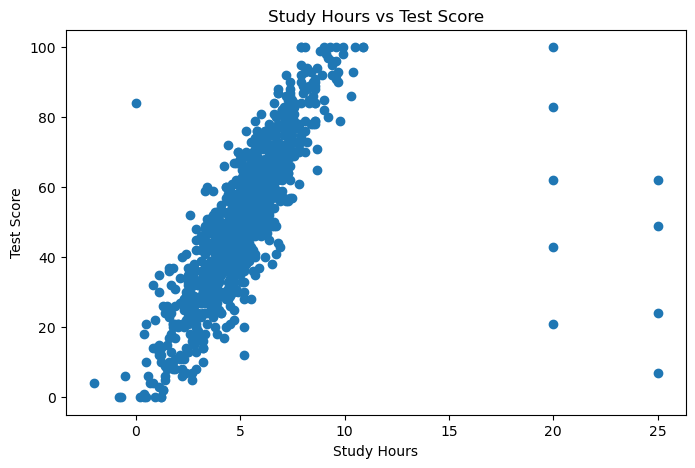

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Test_Score"]
)

plt.xlabel("Study Hours")
plt.ylabel("Test Score")
plt.title("Study Hours vs Test Score")

plt.show()

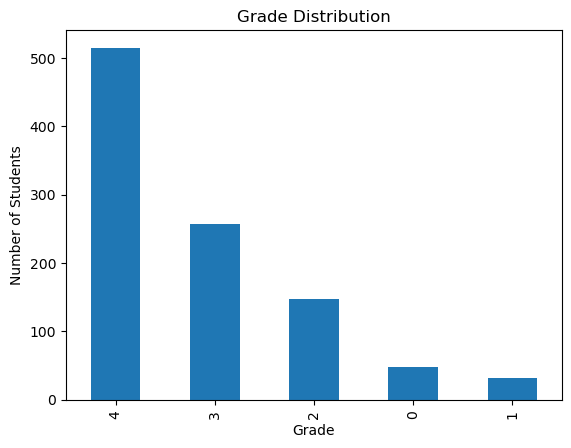

In [12]:
df["Grade"].value_counts().plot(kind="bar")

plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Grade Distribution")

plt.show()

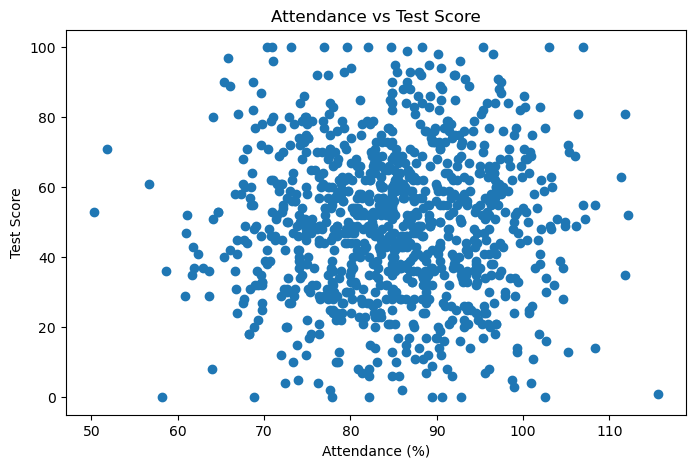

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Attendance(%)"],
    df["Test_Score"]
)

plt.xlabel("Attendance (%)")
plt.ylabel("Test Score")
plt.title("Attendance vs Test Score")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# features and target
X = df[
    [
        "Age",
        "Study_Hours",
        "Attendance(%)"
    ]
]

y = df["Test_Score"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("\n")

X_train: (800, 3)
X_test: (200, 3)
y_train: (800,)
y_test: (200,)




In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [16]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

# prediction
linear_pred = linear_model.predict(
    X_test_scaled
)

print("Linear Regression prediction completed.")

Linear Regression prediction completed.


In [17]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

# Decision Tree does not require scaling
tree_model.fit(
    X_train,
    y_train
)

# prediction
tree_pred = tree_model.predict(
    X_test
)

print("Decision Tree prediction completed.")

Decision Tree prediction completed.


In [18]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Random Forest does not require scaling
forest_model.fit(
    X_train,
    y_train
)

# prediction
forest_pred = forest_model.predict(
    X_test
)

print("Random Forest prediction completed.")

Random Forest prediction completed.


In [19]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

result = []

# Linear Regression
result.append([
    "Linear Regression",
    r2_score(y_test, linear_pred),
    mean_absolute_error(y_test, linear_pred),
    mean_squared_error(y_test, linear_pred)
])

# Decision Tree
result.append([
    "Decision Tree",
    r2_score(y_test, tree_pred),
    mean_absolute_error(y_test, tree_pred),
    mean_squared_error(y_test, tree_pred)
])

# Random Forest
result.append([
    "Random Forest",
    r2_score(y_test, forest_pred),
    mean_absolute_error(y_test, forest_pred),
    mean_squared_error(y_test, forest_pred)
])

# create comparison table
comparison = pd.DataFrame(
    result,
    columns=[
        "Model",
        "R2",
        "MAE",
        "MSE"
    ]
)

print("Comparison Table:")
print(comparison.round(3))

Comparison Table:
               Model     R2     MAE      MSE
0  Linear Regression  0.531  11.652  228.599
1      Decision Tree  0.547  11.120  220.560
2      Random Forest  0.732   8.814  130.373


In [22]:
def predict_marks():

    age = int(input("Enter age: "))
    hours = float(input("Enter study hours: "))
    attendance = float(input("Enter attendance percentage: "))

    new_data = pd.DataFrame({
        "Age": [age],
        "Study_Hours": [hours],
        "Attendance(%)": [attendance]
    })

    prediction = forest_model.predict(
        new_data
    )

    print(
        "Predicted Test Score:",
        round(prediction[0], 2)
    )


predict_marks()

Predicted Test Score: 62.11


In [23]:
# features and target
X = df[
    [
        "Age",
        "Study_Hours",
        "Attendance(%)",
        "Test_Score"
    ]
]

y = df["Grade"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

# prediction
y_pred = classifier.predict(X_test)

print("Grade classification completed.")

Grade classification completed.


In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Accuracy: 0.995
Precision: 0.9954545454545455
Recall: 0.995
F1 Score: 0.9949523809523809

Confusion Matrix:
[[ 10   0   0   0   0]
 [  1   7   0   0   0]
 [  0   0  30   0   0]
 [  0   0   0  49   0]
 [  0   0   0   0 103]]


In [25]:
import joblib

# create models folder manually if it does not exist

# save regression model
joblib.dump(
    forest_model,
    "../models/student_score_model.pkl"
)

# save scaler
joblib.dump(
    scaler,
    "../models/student_scaler.pkl"
)

# save classification model
joblib.dump(
    classifier,
    "../models/student_grade_model.pkl"
)

print("Models saved successfully.")

Models saved successfully.
